# 📊 Notebook 4 — Análisis comparativo de resultados ANN

Esta notebook consolida y visualiza los resultados del benchmark ANN obtenidos en las notebooks anteriores.

El análisis se organiza en tres partes:

1. carga y unificación de los CSV de resultados de los tres modelos de embeddings;
2. curvas Recall vs QPS y tabla comparativa para embeddings independientes;
3. comparación entre representaciones independientes y acumulativas para Dialog2Flow, incluyendo una proyección UMAP.

## 1️⃣ Montaje de Google Drive

Montamos Google Drive para acceder a los archivos de resultados generados en las corridas anteriores.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 2️⃣ Carga de resultados

Importamos las dependencias necesarias y cargamos los CSV exportados por las notebooks de benchmark.

Cada CSV corresponde a un modelo de embeddings: `all-MiniLM-L6-v2`, `all-mpnet-base-v2` y `dialog2flow-joint-bert-base`.
Se agrega la columna `representacion` para facilitar el filtrado y la visualización comparativa.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# === Rutas a los CSV de resultados ===
# Ajustá los nombres según los archivos exportados por tus corridas.
ruta_resultados = Path("/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados")

csv_minilm = ruta_resultados / "resultados_ann_all_MiniLM_L6_v2_20260514_114908_ARG.csv"
csv_mpnet = ruta_resultados / "resultados_ann_all_mpnet_base_v2_20260514_125014_ARG.csv"
csv_d2f = ruta_resultados / "resultados_ann_dialog2flow_joint_bert_base_20260528_092249_ARG.csv"

# === Carga de resultados ===
df_minilm = pd.read_csv(csv_minilm)
df_mpnet = pd.read_csv(csv_mpnet)
df_d2f = pd.read_csv(csv_d2f)

df_minilm["representacion"] = "MiniLM"
df_mpnet["representacion"] = "MPNet"
df_d2f["representacion"] = "Dialog2Flow"

df_all = pd.concat([df_minilm, df_mpnet, df_d2f], ignore_index=True)

## 3️⃣ Filtrado y preparación

Filtramos los datos para retener únicamente las filas correspondientes a embeddings independientes (un vector por turno), que son el foco del benchmark principal.

También se define el orden visual de los índices ANN evaluados: IVF, HNSW e IVFPQ.

In [7]:
# === Filtrar solo embeddings independientes si existe la columna representation ===
# En algunas notebooks puede aparecer como "static_turn_embeddings".
if "representation" in df_all.columns:
    df_plot = df_all[df_all["representation"].isin(["static_turn_embeddings", "embeddings", "independent"])]
    if len(df_plot) == 0:
        df_plot = df_all.copy()
else:
    df_plot = df_all.copy()

# === Orden visual de técnicas ===
orden_indices = ["IVF", "HNSW", "IVFPQ"]


## 4️⃣ Curva Recall@100 vs QPS

Visualizamos el compromiso entre calidad de recuperación (`Recall@100`) y velocidad (`QPS`) para cada método ANN.

Cada panel corresponde a un modelo de embeddings. La línea punteada horizontal indica el recall exacto de `FlatL2` como referencia.

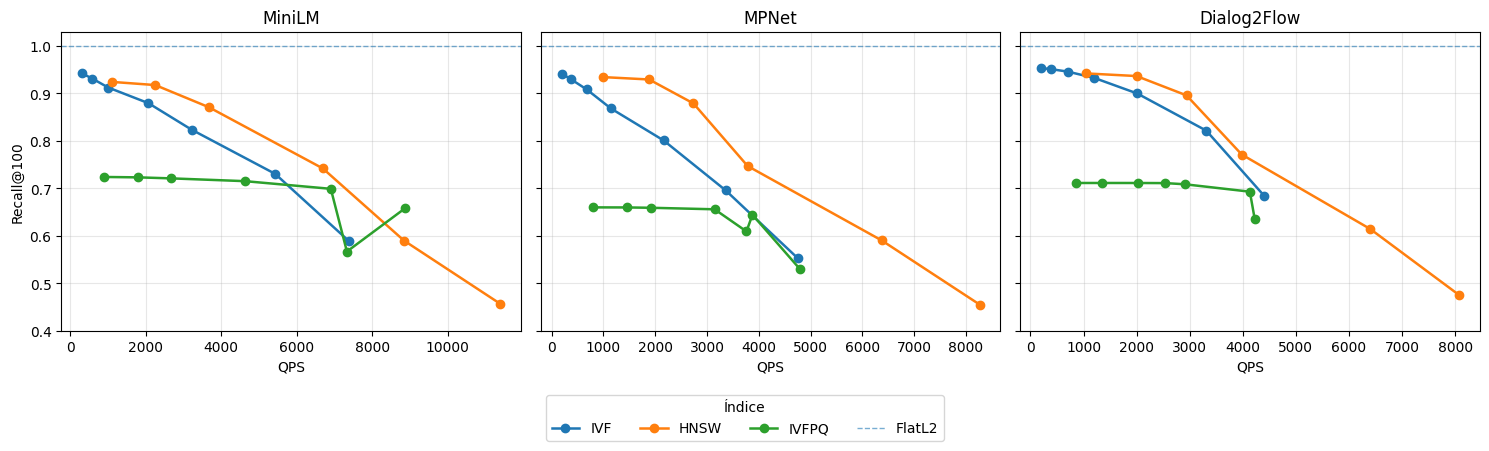

Figura guardada en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/figuras/fig_recall100_qps_embeddings_independientes.pdf
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/figuras/fig_recall100_qps_embeddings_independientes.png


In [12]:
# === Figura Recall@100 vs QPS ===

representaciones = ["MiniLM", "MPNet", "Dialog2Flow"]

label_indices = {
    "IVF": "IVF",
    "HNSW": "HNSW",
    "IVFPQ": "IVFPQ",
}

ruta_figuras = ruta_resultados / "figuras"
ruta_figuras.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, rep in zip(axes, representaciones):
    subset_rep = df_plot[df_plot["representacion"] == rep].copy()

    for index_type in orden_indices:
        subset = subset_rep[subset_rep["index_type"] == index_type].copy()

        if subset.empty:
            continue

        subset = subset.sort_values("qps")

        ax.plot(
            subset["qps"],
            subset["recall@100"],
            marker="o",
            linewidth=1.8,
            label=label_indices.get(index_type, index_type)
        )

    # Línea de referencia: búsqueda exacta FlatL2
    ax.axhline(
        y=1.0,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        label="FlatL2"
    )

    ax.set_title(rep)
    ax.set_xlabel("QPS")
    ax.set_ylim(0.40, 1.03)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Recall@100")

# === Leyenda única, evitando etiquetas repetidas ===
handles, labels = [], []

for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(
    handles,
    labels,
    title="Índice",
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.08)
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

# === Guardado ===
salida_pdf = ruta_figuras / "fig_recall100_qps_embeddings_independientes.pdf"
salida_png = ruta_figuras / "fig_recall100_qps_embeddings_independientes.png"

plt.savefig(salida_pdf, bbox_inches="tight")
plt.savefig(salida_png, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(salida_pdf)
print(salida_png)

## 5️⃣ Curvas Recall@10 y Recall@100 vs QPS

Extendemos el análisis anterior incluyendo `Recall@10`, relevante para aplicaciones de recuperación que presentan pocos resultados al usuario.

La cuadrícula de 2 × 3 permite comparar simultáneamente ambas métricas en los tres modelos de embeddings.

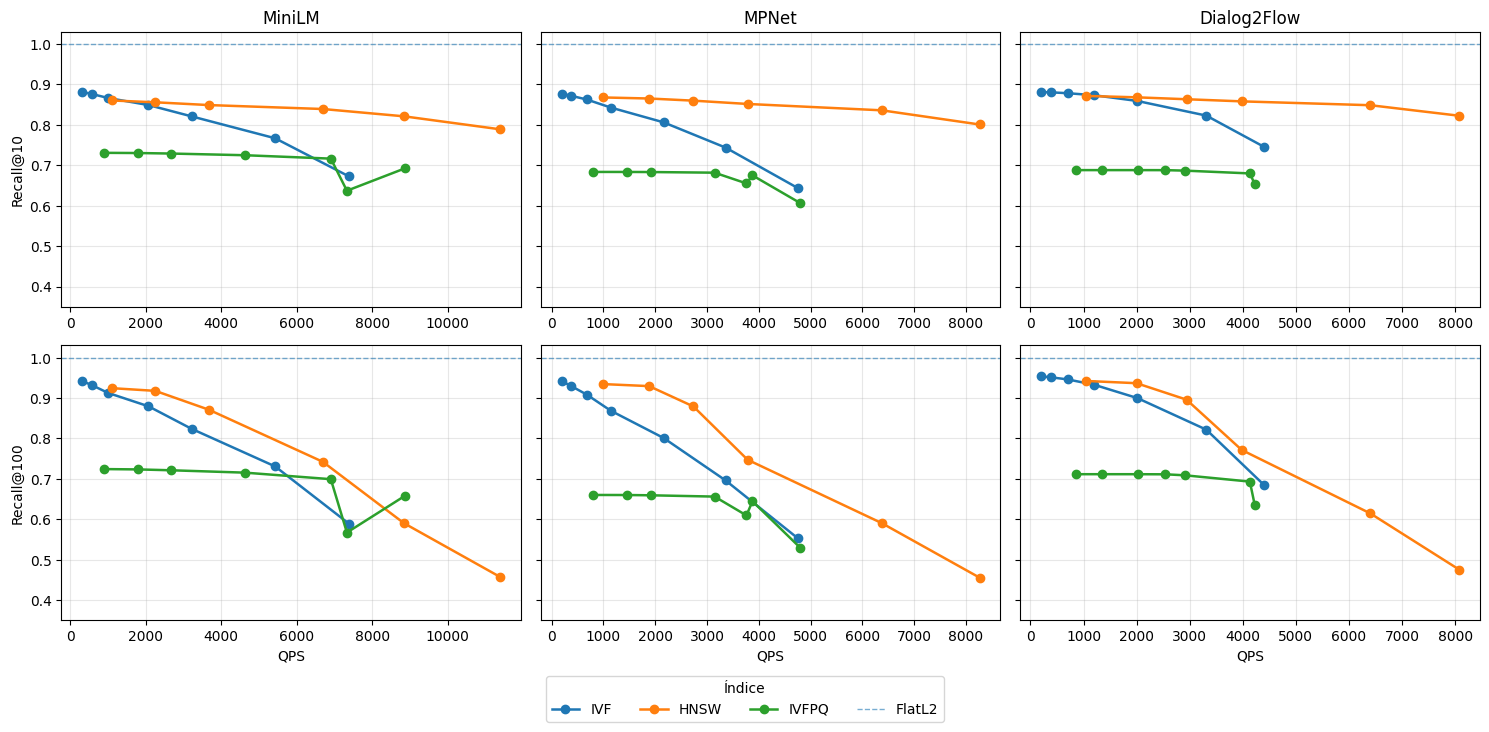

Figura guardada en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/figuras/fig_recall10_recall100_qps_embeddings_independientes.pdf
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/figuras/fig_recall10_recall100_qps_embeddings_independientes.png


In [13]:
# === Figura Recall@10 y Recall@100 vs QPS ===

# Quitamos FlatL2 de las curvas, pero lo usamos como referencia visual
df_plot_ann = df_plot[df_plot["index_type"] != "FlatL2"].copy()

representaciones = ["MiniLM", "MPNet", "Dialog2Flow"]
recall_metrics = ["recall@10", "recall@100"]
recall_labels = ["Recall@10", "Recall@100"]

label_indices = {
    "IVF": "IVF",
    "HNSW": "HNSW",
    "IVFPQ": "IVFPQ",
}

ruta_figuras = ruta_resultados / "figuras"
ruta_figuras.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 7.2),
    sharey="row"
)

for row_idx, (metric, metric_label) in enumerate(zip(recall_metrics, recall_labels)):
    for col_idx, rep in enumerate(representaciones):
        ax = axes[row_idx, col_idx]

        subset_rep = df_plot_ann[df_plot_ann["representacion"] == rep].copy()

        for index_type in orden_indices:
            subset = subset_rep[subset_rep["index_type"] == index_type].copy()

            if subset.empty:
                continue

            subset = subset.sort_values("qps")

            ax.plot(
                subset["qps"],
                subset[metric],
                marker="o",
                linewidth=1.8,
                label=label_indices.get(index_type, index_type)
            )

        # Referencia exacta FlatL2
        ax.axhline(
            y=1.0,
            linestyle="--",
            linewidth=1,
            alpha=0.6,
            label="FlatL2"
        )

        if row_idx == 0:
            ax.set_title(rep)

        if row_idx == 1:
            ax.set_xlabel("QPS")

        if col_idx == 0:
            ax.set_ylabel(metric_label)

        ax.set_ylim(0.35, 1.03)
        ax.grid(True, alpha=0.3)

# Leyenda única sin repetidos
handles, labels = [], []

for ax in axes.ravel():
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(
    handles,
    labels,
    title="Índice",
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

# Guardado
salida_pdf = ruta_figuras / "fig_recall10_recall100_qps_embeddings_independientes.pdf"
salida_png = ruta_figuras / "fig_recall10_recall100_qps_embeddings_independientes.png"

plt.savefig(salida_pdf, bbox_inches="tight")
plt.savefig(salida_png, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(salida_pdf)
print(salida_png)

## 6️⃣ Tabla de resultados representativos

Construimos una tabla resumen con las configuraciones más relevantes de cada índice: `FlatL2` (referencia exacta), `IVF` con `nprobe=64`, `HNSW` con `efSearch=256` e `IVFPQ` con `nprobe=64`.

La tabla se exporta en formato CSV y LaTeX para su inclusión directa en el paper.

In [14]:
import numpy as np

# ============================================================
# Tabla representativa de embeddings independientes
# ============================================================

df_tabla = df_all.copy()

# Normalización defensiva de nombres de columnas
rename_map = {
    "recall_1": "recall@1",
    "recall_10": "recall@10",
    "recall_100": "recall@100",
    "Recall@1": "recall@1",
    "Recall@10": "recall@10",
    "Recall@100": "recall@100",
    "QPS": "qps",
    "memory": "memory_mb",
    "memory_estimated_mb": "memory_mb",
    "estimated_memory_mb": "memory_mb",
    "build_time": "build_time_s",
    "build_time_seconds": "build_time_s",
}

df_tabla = df_tabla.rename(columns={k: v for k, v in rename_map.items() if k in df_tabla.columns})

print("Columnas disponibles:")
print(df_tabla.columns.tolist())

# ============================================================
# Función auxiliar para seleccionar configuraciones
# ============================================================

def seleccionar_config(df, representacion, index_type, param_col=None, param_value=None):
    sub = df[
        (df["representacion"] == representacion) &
        (df["index_type"] == index_type)
    ].copy()

    if param_col is not None and param_col in sub.columns:
        sub = sub[sub[param_col] == param_value].copy()

    if sub.empty:
        print(f"No se encontró: {representacion} | {index_type} | {param_col}={param_value}")
        return None

    # Si hubiera más de una fila, tomamos la de mayor Recall@100 y luego mayor QPS
    sub = sub.sort_values(["recall@100", "qps"], ascending=[False, False])
    return sub.iloc[0]

# ============================================================
# Detectar nombres posibles de columnas de parámetros
# ============================================================

possible_nprobe_cols = ["nprobe", "param_nprobe"]
possible_ef_cols = ["efSearch", "ef_search", "efsearch", "param_efSearch"]

nprobe_col = next((c for c in possible_nprobe_cols if c in df_tabla.columns), None)
ef_col = next((c for c in possible_ef_cols if c in df_tabla.columns), None)

print("Columna nprobe:", nprobe_col)
print("Columna efSearch:", ef_col)

# ============================================================
# Selección de filas representativas
# ============================================================

filas = []

for rep in ["MiniLM", "MPNet", "Dialog2Flow"]:
    configuraciones = [
        ("FlatL2", None, None, "FlatL2"),
        ("IVF", nprobe_col, 64, r"IVF $nprobe=64$"),
        ("HNSW", ef_col, 256, r"HNSW $efSearch=256$"),
        ("IVFPQ", nprobe_col, 64, r"IVFPQ $nprobe=64$"),
    ]

    for index_type, param_col, param_value, etiqueta in configuraciones:
        row = seleccionar_config(df_tabla, rep, index_type, param_col, param_value)

        if row is None:
            continue

        filas.append({
            "Representación": rep,
            "Índice/config.": etiqueta,
            "R@1": row.get("recall@1", np.nan),
            "R@10": row.get("recall@10", np.nan),
            "R@100": row.get("recall@100", np.nan),
            "QPS": row.get("qps", np.nan),
            "Mem. (MB)": row.get("memory_mb", np.nan),
            "Build (s)": row.get("build_time_s", np.nan),
        })

tabla_repr = pd.DataFrame(filas)

# ============================================================
# Redondeo para visualización
# ============================================================

tabla_display = tabla_repr.copy()

for col in ["R@1", "R@10", "R@100"]:
    if col in tabla_display.columns:
        tabla_display[col] = tabla_display[col].map(lambda x: f"{x:.3f}" if pd.notnull(x) else "--")

for col in ["QPS"]:
    if col in tabla_display.columns:
        tabla_display[col] = tabla_display[col].map(lambda x: f"{x:.0f}" if pd.notnull(x) else "--")

for col in ["Mem. (MB)", "Build (s)"]:
    if col in tabla_display.columns:
        tabla_display[col] = tabla_display[col].map(lambda x: f"{x:.1f}" if pd.notnull(x) else "--")

display(tabla_display)

# ============================================================
# Exportar CSV y LaTeX
# ============================================================

ruta_tabla_csv = ruta_resultados / "tabla_resultados_representativos_independientes.csv"
ruta_tabla_tex = ruta_resultados / "tabla_resultados_representativos_independientes.tex"

tabla_display.to_csv(ruta_tabla_csv, index=False)

latex_table = tabla_display.to_latex(
    index=False,
    escape=False,
    column_format="llrrrrrr"
)

with open(ruta_tabla_tex, "w", encoding="utf-8") as f:
    f.write(latex_table)

print("Tabla CSV guardada en:")
print(ruta_tabla_csv)

print("\nTabla LaTeX guardada en:")
print(ruta_tabla_tex)

print("\nCódigo LaTeX:")
print(latex_table)

Columnas disponibles:
['embedding_model', 'index_type', 'params', 'nlist', 'nprobe', 'M', 'efConstruction', 'efSearch', 'm', 'nbits', 'num_index_vectors', 'num_query_vectors', 'dimension', 'build_time_s', 'search_time_s', 'qps', 'recall@1', 'recall@10', 'recall@100', 'memory_mb', 'representacion']
Columna nprobe: nprobe
Columna efSearch: efSearch


,Representación,Índice/config.,R@1,R@10,R@100,QPS,Mem. (MB),Build (s)
0,MiniLM,FlatL2,1.000,1.000,1.000,62,1450.2,1.8
1,MiniLM,IVF $nprobe=64$,0.692,0.881,0.942,320,1463.8,123.0
2,MiniLM,HNSW $efSearch=256$,0.674,0.860,0.924,1115,1691.9,1015.5
3,MiniLM,IVFPQ $nprobe=64$,0.757,0.731,0.724,900,44.1,155.9
4,MPNet,FlatL2,1.000,1.000,1.000,32,2900.5,7.6
5,MPNet,IVF $nprobe=64$,0.668,0.877,0.942,195,2920.0,240.8
6,MPNet,HNSW $efSearch=256$,0.660,0.868,0.934,1001,3142.2,1348.1
7,MPNet,IVFPQ $nprobe=64$,0.730,0.683,0.660,791,50.5,336.6
8,Dialog2Flow,FlatL2,1.000,1.000,1.000,34,2900.5,3.6
9,Dialog2Flow,IVF $nprobe=64$,0.685,0.881,0.953,203,2920.0,237.4


Tabla CSV guardada en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/tabla_resultados_representativos_independientes.csv

Tabla LaTeX guardada en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/tabla_resultados_representativos_independientes.tex

Código LaTeX:
\begin{tabular}{llrrrrrr}
\toprule
Representación & Índice/config. & R@1 & R@10 & R@100 & QPS & Mem. (MB) & Build (s) \\
\midrule
MiniLM & FlatL2 & 1.000 & 1.000 & 1.000 & 62 & 1450.2 & 1.8 \\
MiniLM & IVF $nprobe=64$ & 0.692 & 0.881 & 0.942 & 320 & 1463.8 & 123.0 \\
MiniLM & HNSW $efSearch=256$ & 0.674 & 0.860 & 0.924 & 1115 & 1691.9 & 1015.5 \\
MiniLM & IVFPQ $nprobe=64$ & 0.757 & 0.731 & 0.724 & 900 & 44.1 & 155.9 \\
MPNet & FlatL2 & 1.000 & 1.000 & 1.000 & 32 & 2900.5 & 7.6 \\
MPNet & IVF $nprobe=64$ & 0.668 & 0.877 & 0.942 & 195 & 2920.0 & 240.8 \\
MPNet & HNSW $efSearch=256$ & 0.660 & 0.868 & 0.934 & 1001 & 3142.2 & 1348.1 \\
MPNet & IVFPQ $nprobe=64$ & 0.730 & 0.683 & 0.660 & 791 & 50.5 & 336.6 \\
Di

## 7️⃣ Configuración para el análisis de Dialog2Flow acumulativo

Definimos las rutas a los archivos necesarios para comparar las representaciones independientes y acumulativas de Dialog2Flow:

- `embeddings_dialog2flow.npy`: embeddings independientes (un vector por turno).
- `accumulative_embeddings_dialog2flow.npy`: embeddings acumulativos (promedio de los turnos previos del diálogo).
- CSV de resultados ANN sobre la representación dinámica.

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

# ============================================================
# Rutas
# ============================================================

ruta_data = Path("/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0")

csv_d2f_dynamic = ruta_resultados / "resultados_dynamic_states_dialog2flow_joint_bert_base_20260528_113058_ARG.csv"


ruta_static = ruta_data / "embeddings_dialog2flow.npy"
ruta_accum = ruta_data / "accumulative_embeddings_dialog2flow.npy"

ruta_figuras = ruta_resultados / "figuras"
ruta_figuras.mkdir(parents=True, exist_ok=True)

## 8️⃣ Comparación independiente vs acumulativo — Recall y UMAP

Analizamos si la representación acumulativa del contexto de diálogo produce vecindades de recuperación diferentes a la representación independiente.

El panel izquierdo muestra las curvas `Recall@100 vs QPS` para ambas representaciones sobre los índices IVF y HNSW.
El panel derecho muestra una proyección UMAP de una muestra de 3.000 embeddings de cada tipo, para visualizar la geometría de ambos espacios.

Columnas:
['representation', 'index_type', 'params', 'recall@1', 'recall@10', 'recall@100', 'qps', 'search_time_s', 'build_time_s', 'memory_mb', 'num_index_vectors', 'num_queries', 'dimension', 'embedding_model', 'nlist', 'nprobe', 'M', 'efConstruction', 'efSearch']
Representaciones disponibles:
['base_embeddings' 'accumulative_normalized_embeddings']
Embeddings independientes: (1000023, 768)
Embeddings acumulativos: (1000023, 768)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


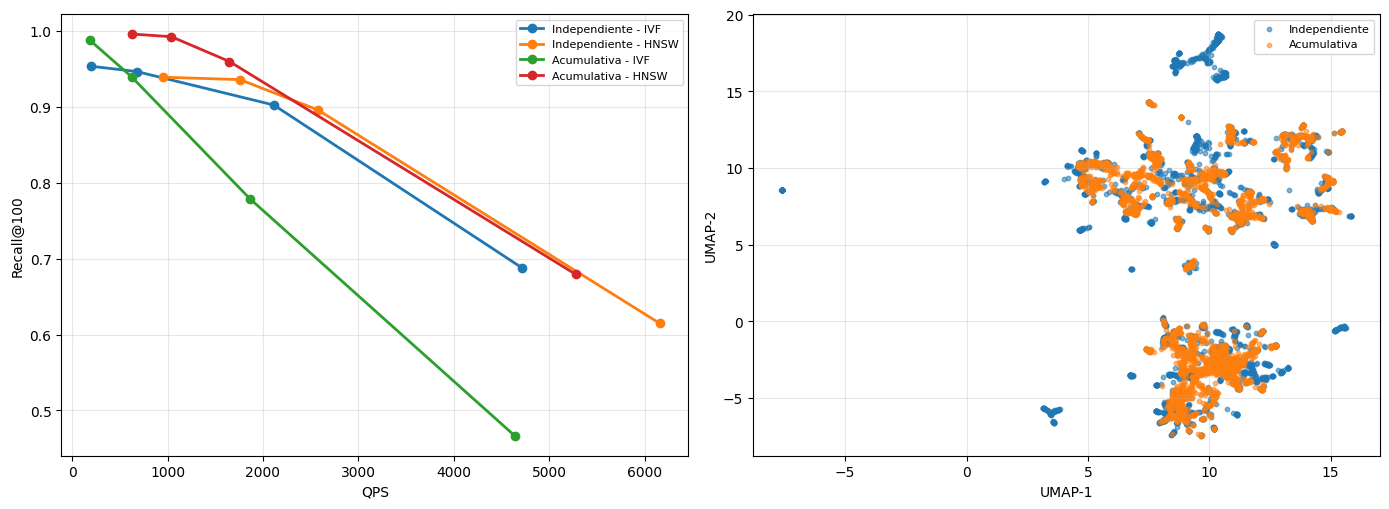

Figura guardada en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/figuras/fig_dialog2flow_independiente_vs_acumulativa_1x2.pdf
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/figuras/fig_dialog2flow_independiente_vs_acumulativa_1x2.png


In [23]:
# ============================================================
# Cargar resultados ANN de Dialog2Flow
# ============================================================

df = pd.read_csv(csv_d2f_dynamic)

print("Columnas:")
print(df.columns.tolist())

print("Representaciones disponibles:")
print(df["representation"].unique())

# ============================================================
# Preparar datos para el panel izquierdo
# ============================================================

df_plot = df[df["index_type"].isin(["IVF", "HNSW"])].copy()

def sort_subset(sub):
    if sub["index_type"].iloc[0] == "IVF":
        return sub.sort_values("nprobe")
    elif sub["index_type"].iloc[0] == "HNSW":
        return sub.sort_values("efSearch")
    return sub.sort_values("qps")

label_map = {
    ("base_embeddings", "IVF"): "Independiente - IVF",
    ("base_embeddings", "HNSW"): "Independiente - HNSW",
    ("static_turn_embeddings", "IVF"): "Independiente - IVF",
    ("static_turn_embeddings", "HNSW"): "Independiente - HNSW",
    ("accumulative_normalized_embeddings", "IVF"): "Acumulativa - IVF",
    ("accumulative_normalized_embeddings", "HNSW"): "Acumulativa - HNSW",
}

# ============================================================
# Cargar embeddings para UMAP
# ============================================================

emb_static = np.load(ruta_static)
emb_accum = np.load(ruta_accum)

print("Embeddings independientes:", emb_static.shape)
print("Embeddings acumulativos:", emb_accum.shape)

# ============================================================
# Muestreo para UMAP
# ============================================================

N_UMAP = 3000
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

n_total = min(len(emb_static), len(emb_accum))
idx = np.random.choice(n_total, size=min(N_UMAP, n_total), replace=False)

sample_static = emb_static[idx]
sample_accum = emb_accum[idx]

X_umap = np.vstack([sample_static, sample_accum])

labels_umap = np.array(
    ["Independiente"] * len(sample_static) +
    ["Acumulativa"] * len(sample_accum)
)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=RANDOM_STATE
)

X_2d = reducer.fit_transform(X_umap)

# ============================================================
# Figura 1x2
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# ------------------------------------------------------------
# Panel izquierdo: Recall@100 vs QPS
# ------------------------------------------------------------

ax = axes[0]

for representation in df_plot["representation"].unique():
    for index_type in ["IVF", "HNSW"]:
        subset = df_plot[
            (df_plot["representation"] == representation) &
            (df_plot["index_type"] == index_type)
        ].copy()

        if subset.empty:
            continue

        subset = sort_subset(subset)

        ax.plot(
            subset["qps"],
            subset["recall@100"],
            marker="o",
            linewidth=2,
            label=label_map.get(
                (representation, index_type),
                f"{representation} - {index_type}"
            )
        )

ax.set_xlabel("QPS")
ax.set_ylabel("Recall@100")
#ax.set_title("a) Recuperación aproximada")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# ------------------------------------------------------------
# Panel derecho: UMAP
# ------------------------------------------------------------

ax = axes[1]

mask_static = labels_umap == "Independiente"
mask_accum = labels_umap == "Acumulativa"

ax.scatter(
    X_2d[mask_static, 0],
    X_2d[mask_static, 1],
    s=10,
    alpha=0.55,
    label="Independiente"
)

ax.scatter(
    X_2d[mask_accum, 0],
    X_2d[mask_accum, 1],
    s=10,
    alpha=0.55,
    label="Acumulativa"
)

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
#ax.set_title("b) Proyección UMAP")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()

# ============================================================
# Guardado
# ============================================================

salida_pdf = ruta_figuras / "fig_dialog2flow_independiente_vs_acumulativa_1x2.pdf"
salida_png = ruta_figuras / "fig_dialog2flow_independiente_vs_acumulativa_1x2.png"

plt.savefig(salida_pdf, bbox_inches="tight")
plt.savefig(salida_png, dpi=300, bbox_inches="tight")

plt.show()

print("Figura guardada en:")
print(salida_pdf)
print(salida_png)